d:\ChurnShield-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


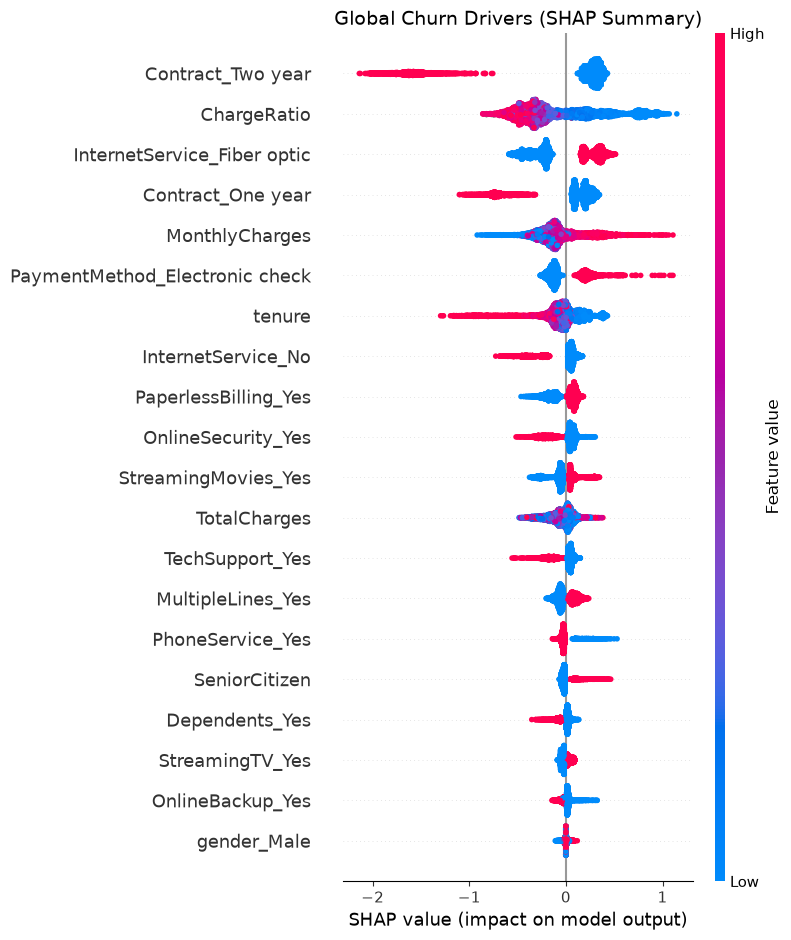

Customer 0 Base Value vs Prediction SHAP Analysis:


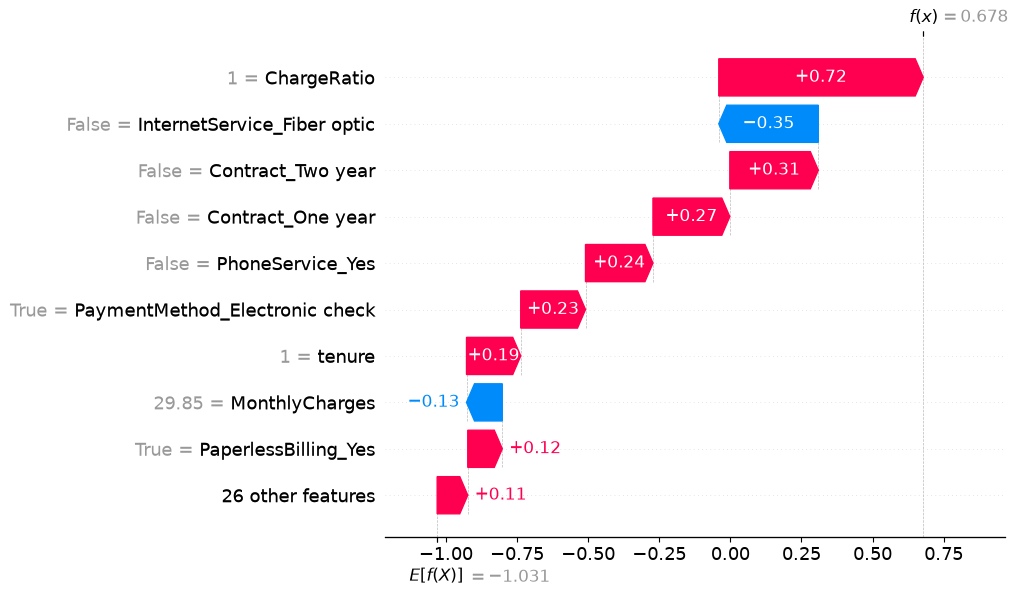

In [1]:
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

# Load engineering data and trained model
df = pd.read_csv('../data/engineered_churn_data.csv')
model = joblib.load('../saved_models/xgboost_churn_model.pkl')

# target and features setup
target_col = 'Churn' if 'Churn' in df.columns else [col for col in df.columns if 'Churn' in col][0]
X = df.drop(columns=[target_col, 'customerID'], errors='ignore')

# intialize SHAP explainer 
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

# global drivers (overall impacte features) plot
plt.title("Global Churn Drivers (SHAP Summary)", fontsize=14)
shap.summary_plot(shap_values, X, show=False)
plt.savefig('../saved_models/shap_summary.png', bbox_inches='tight')
plt.show()

# loocal driver (single ucstomer analysis example)
sample_idx = 0  # 1st customer complete churn driver
print(f"Customer {sample_idx} Base Value vs Prediction SHAP Analysis:")
shap.plots.waterfall(shap_values[sample_idx])